ES 7.2

In [28]:
from generator import rand_exp
import numpy as np
tau = 1
tau_max = 5 
N = 1000                        
randlist = []
for i in range(N): 
    total_time = rand_exp(tau)
    events = 0
    while (total_time < tau_max) :
        events = events + 1
        total_time = total_time + rand_exp(tau)
    randlist.append(events)

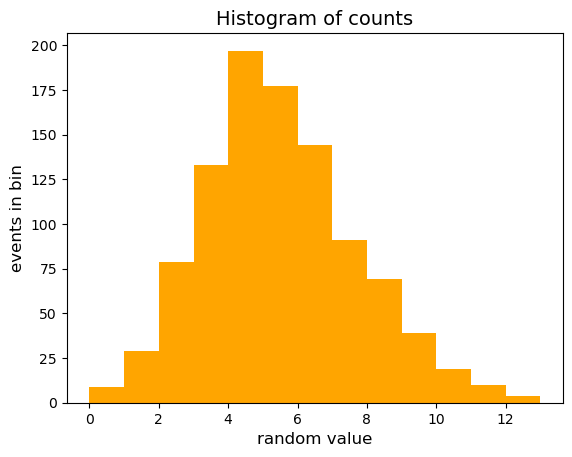

In [29]:
import matplotlib.pyplot as plt
import numpy as np 
from math import ceil, floor
from statistics import mean, stdev
xMin = max(0., ceil( mean(randlist) - 4*stdev(randlist)))
xMax = floor( mean(randlist) + 4*stdev(randlist))
N_bins = int(xMax - xMin)
bins_edges = np.linspace( xMin, xMax, N_bins + 1)
fig, ax = plt.subplots( ncols = 1, nrows = 1)
ax.hist(randlist, bins = bins_edges, color = 'orange')
plt.title('Histogram of counts', size = 14)
ax.set_xlabel('random value', size = 12)
ax.set_ylabel('events in bin', size = 12)
plt.show()

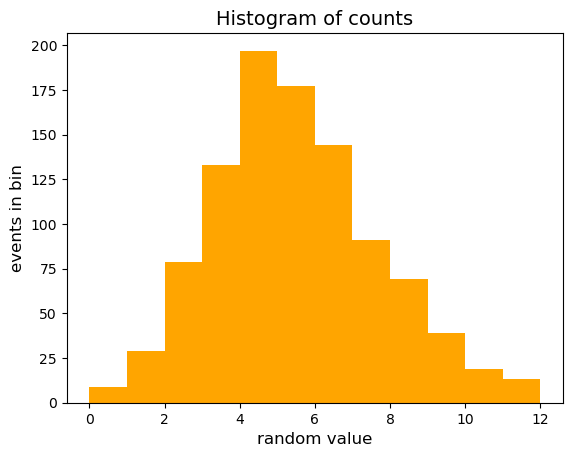

In [30]:
import matplotlib.pyplot as plt
import numpy as np 
from math import ceil, floor
from statistics import mean, stdev
xMin = max(0., ceil(mean(randlist) - 3*stdev(randlist)))
xMax = ceil(mean(randlist) + 3*stdev(randlist))
N_bins = floor(len(randlist)/100)
bins_edges = np.linspace( xMin, xMax, int(xMax - xMin) + 1)
fig, ax = plt.subplots( ncols = 1, nrows = 1)
ax.hist(randlist, bins = bins_edges, color = 'orange')
plt.title('Histogram of counts', size = 14)
ax.set_xlabel('random value', size = 12)
ax.set_ylabel('events in bin', size = 12)
plt.show()

Exercise 7.4
- Use the result from the previous exercise to calculate the statistics of a Poisson distribution varying the mean, from 1 to 250 (how should you sample the interval?).
- Plot the obtained behavior of skewness and kurtosis as function of the Poisson mean.


In [57]:
from generator import generate_poisson
import numpy as np 
from skew_kurt import stats
starting_mean = 1
final_mean = 10
N = 100
means = []
skewn = []
kurts = []
while (starting_mean < final_mean) :
    randlist = generate_poisson (starting_mean, N) 
    my_stats = stats(randlist)
    means.append (my_stats.mean())
    skewn.append (my_stats.skewness())
    kurts.append (my_stats.kurtosis())
    starting_mean *= 2

Text(0.5, 0, 'mean')

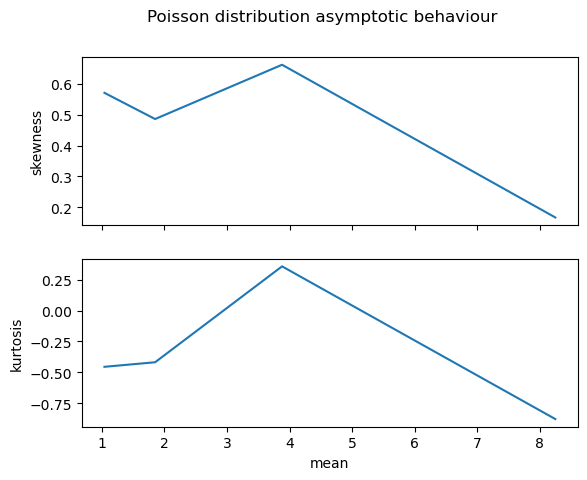

In [58]:
import matplotlib.pyplot as plt
import numpy as np 
fig, (ax1, ax2) = plt.subplots (2, sharex = True)
fig.suptitle ('Poisson distribution asymptotic behaviour')
ax1.plot (means, skewn)
ax1.set_ylabel ('skewness')
ax2.plot (means, kurts)
ax2.set_ylabel ('kurtosis')
ax2.set_xlabel ('mean')